# EDA — Psych8k (neutral LLM-judge benchmark)

| Item | Detail |
|---|---|
| **Source** | [`EmoCareAI/Psych8k`](https://huggingface.co/datasets/EmoCareAI/Psych8k) — 8,187 Q&A pairs from ~260 real counseling recordings |
| **Access** | Gated on HF (accept conditions once) + `huggingface-cli login`. License CC-BY-NC-SA-4.0 (research use) |
| **Schema** | `instruction` (fixed boilerplate) · `input` (patient message) → `output` (counselor reply) |
| **Purpose** | Held-out **neutral benchmark** for the LLM-as-judge evaluation — belongs to *neither* training dataset, so all 6 tuned models compete on equal ground (the MentalChat16K paper's method) |
| **Output** | 200-question subset (seed from config) → `data/mh_conversation/benchmark/psych8k_test200.csv` |

In [1]:
# Cell 1 — Download (gated) + load
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import ft_utils

C_INPUT = "#4477AA"    # blue   — patient/question series
C_OUTPUT = "#EE7733"   # orange — counselor/answer series
C_MEDIAN = "#333333"
plt.rcParams.update({"axes.spines.top": False, "axes.spines.right": False})

BCFG = ft_utils.CFG["judge"]["benchmark"]
try:
    from huggingface_hub import hf_hub_download
    raw_path = hf_hub_download(BCFG["hf_id"], BCFG["raw_filename"], repo_type="dataset")
except Exception as e:
    raise RuntimeError(
        "Could not download Psych8k. It is GATED: open "
        "https://huggingface.co/datasets/EmoCareAI/Psych8k , accept the "
        "conditions, and make sure you are logged in (huggingface-cli login)."
    ) from e

raw = pd.read_json(raw_path)
print(f"Shape (raw): {raw.shape}")
print(f"Columns: {list(raw.columns)}")
print(f"\nUnique instruction values: {raw['instruction'].nunique()}")
print(f"Instruction text: {raw['instruction'].iloc[0][:160]!r}")

Shape (raw): (8187, 3)
Columns: ['instruction', 'input', 'output']

Unique instruction values: 1
Instruction text: 'If you are a counsellor, please answer the questions based on the description of the patient.'


Cleaned shape: (8187, 2) (removed 0 rows)
Unique patient messages: 8187


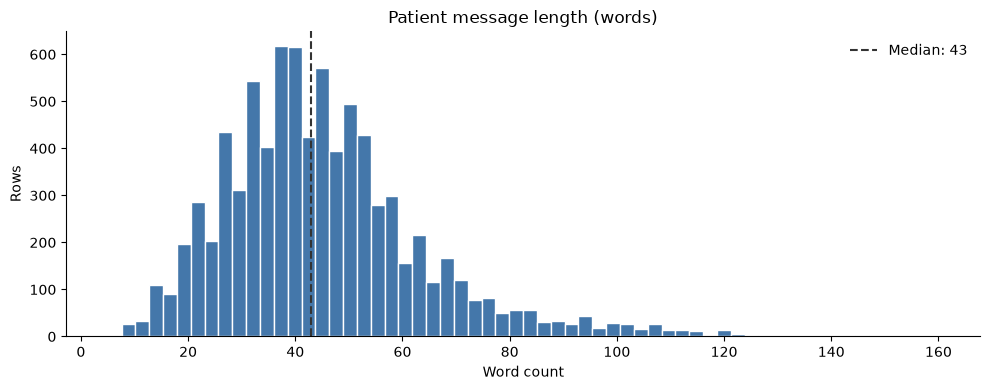

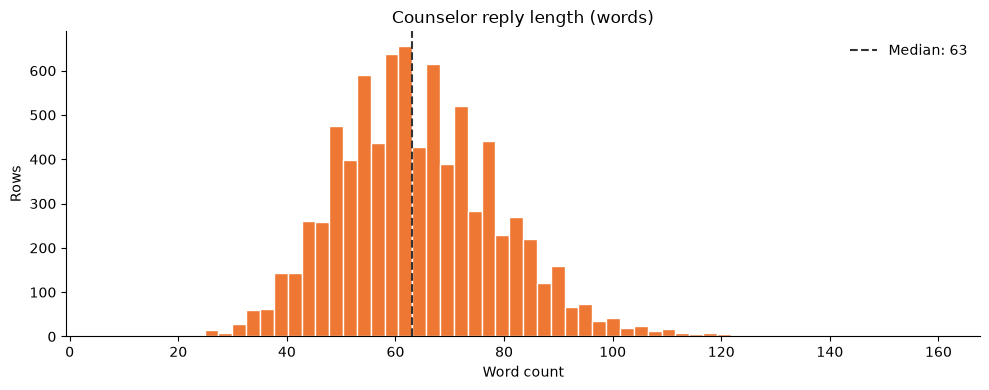

In [2]:
# Cell 2 — Clean + length distributions
df = raw[["input", "output"]].copy()
for col in ("input", "output"):
    df[col] = df[col].fillna("").astype(str).str.strip()
df = df[df["input"].ne("") & df["output"].ne("")]
before = len(df)
df = df.drop_duplicates(subset=["input", "output"]).reset_index(drop=True)
print(f"Cleaned shape: {df.shape} (removed {len(raw) - len(df)} rows)")
print(f"Unique patient messages: {df['input'].nunique()}")

df["input_words"] = df["input"].str.split().str.len()
df["output_words"] = df["output"].str.split().str.len()

for col, color, title in [("input_words", C_INPUT, "Patient message length (words)"),
                          ("output_words", C_OUTPUT, "Counselor reply length (words)")]:
    plt.figure(figsize=(10, 4))
    plt.hist(df[col], bins=60, color=color, edgecolor="white")
    med = df[col].median()
    plt.axvline(med, color=C_MEDIAN, linestyle="--", label=f"Median: {med:.0f}")
    plt.title(title)
    plt.xlabel("Word count")
    plt.ylabel("Rows")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

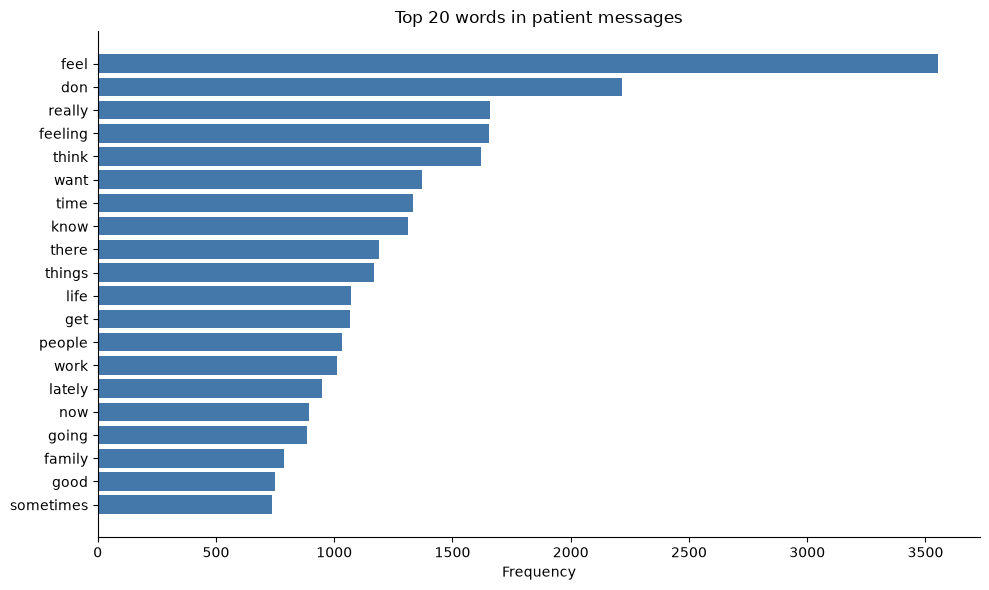

In [3]:
# Cell 3 — Top 20 words in patient messages
stopwords = {"the", "a", "an", "is", "are", "was", "were", "be", "been", "being",
             "have", "has", "had", "do", "does", "did", "will", "would", "could",
             "should", "may", "might", "shall", "can", "need", "dare", "to", "of",
             "in", "for", "on", "with", "at", "by", "from", "as", "into", "through",
             "during", "before", "after", "and", "but", "or", "nor", "not", "so",
             "yet", "both", "either", "neither", "each", "every", "all", "any",
             "few", "more", "most", "other", "some", "such", "no", "only", "own",
             "same", "than", "too", "very", "just", "because", "if", "when", "where",
             "how", "what", "which", "who", "whom", "this", "that", "these", "those",
             "i", "me", "my", "myself", "we", "our", "ours", "you", "your", "yours",
             "he", "him", "his", "she", "her", "hers", "it", "its", "they", "them",
             "their", "theirs", "about", "up", "out", "also", "like", "well", "even"}

words = []
for text in df["input"]:
    words.extend(w for w in re.findall(r"[a-z]+", text.lower())
                 if w not in stopwords and len(w) > 2)
top20 = Counter(words).most_common(20)
labels, counts = zip(*top20)

plt.figure(figsize=(10, 6))
plt.barh(list(reversed(labels)), list(reversed(counts)), color=C_INPUT)
plt.title("Top 20 words in patient messages")
plt.xlabel("Frequency")
plt.tight_layout()
plt.show()

In [4]:
# Cell 4 — Held-out check: overlap with BOTH training datasets
# The benchmark is only fair if no Psych8k question appears in either
# fine-tuning dataset (exact-match on the patient text).
bench_inputs = set(df["input"])
for ds in ft_utils.CFG["datasets"]:
    tr, va, te = ft_utils.load_and_split(ds)
    ds_inputs = set(tr["input"]) | set(va["input"]) | set(te["input"])
    overlap = bench_inputs & ds_inputs
    print(f"{ds}: {len(overlap)} exact-match overlaps with Psych8k")
    assert len(overlap) == 0 or len(overlap) < 5, "benchmark overlaps training data!"
print("OK: Psych8k is effectively disjoint from both training datasets.")

amod: 0 exact-match overlaps with Psych8k
mentalchat16k: 0 exact-match overlaps with Psych8k
OK: Psych8k is effectively disjoint from both training datasets.


In [5]:
# Cell 5 — Sample the 200-question benchmark subset + save CSV
N = ft_utils.CFG["judge"]["benchmark"]["n_questions"]
csv_path = (ft_utils.ROOT / ft_utils.CFG["judge"]["benchmark"]["csv"]).resolve()
csv_path.parent.mkdir(parents=True, exist_ok=True)

pool = df.drop_duplicates(subset=["input"]).reset_index(drop=True)
bench = (pool.sample(n=N, random_state=ft_utils.SEED)
         .reset_index(drop=True)
         .rename(columns={"input": "question", "output": "reference_answer"})
         [["question", "reference_answer"]])
bench.to_csv(csv_path, index=False)
print(f"Saved {len(bench)} questions -> {csv_path}")
print(f"Question words: median {bench['question'].str.split().str.len().median():.0f}, "
      f"max {bench['question'].str.split().str.len().max()}")
bench.head(3)

Saved 200 questions -> C:\Users\laoli\OneDrive\Desktop\MultiAgent2\data\mh_conversation\benchmark\psych8k_test200.csv
Question words: median 43, max 114


,question,reference_answer
0,"I want to quit smoking, but I think it will ta...",It's great that you're considering quitting sm...
1,I had a situation when I was called stubborn b...,It's clear that your mother was a special pers...
2,I'm struggling with understanding certain aspe...,It seems like you have a couple of options her...


## Summary

1. Psych8k: 8,187 real-counseling Q&A pairs; the `instruction` column is one constant boilerplate string (dropped, same as MentalChat16K's).
2. Cell 4 verifies the benchmark is **disjoint from both fine-tuning datasets**, so neither tuned model family has seen these questions — the judge comparison is on neutral ground.
3. The 200-question subset (seed 42) is saved as `data/mh_conversation/benchmark/psych8k_test200.csv` — `evaluate_llm_judge.ipynb` reads it from there. The `reference_answer` column is kept for context only; the judge is reference-free.